In [17]:
# ==============================================
# 🛠️ ENVIRONMENT SETUP (install dependencies into current Jupyter kernel)
# ==============================================

import sys

# Upgrade pip (optional, but recommended)
!{sys.executable} -m pip install --upgrade pip

# Install required libraries into the current kernel's environment
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install numpy pillow tqdm matplotlib seaborn scikit-learn


Looking in indexes: https://download.pytorch.org/whl/cpu


In [18]:
import seaborn as sns
print("✅ Seaborn imported successfully")


✅ Seaborn imported successfully


In [21]:
# ==============================================
# 1. Setup & Imports
# ==============================================
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Add the project root to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Import models and configuration
from src.feature_extraction.resnet2d_extractor import get_resnet18_model
from src.feature_extraction.cnn3d_extractor import get_3dcnn_model
from src.setup import environment_feature_extraction as config

# Define video-specific directories
video_name = "vid_001"
# Use full absolute path to avoid relative path issues
mouth_crop_dir = r"C:\Users\PC\Desktop\phaseB\VisoSpeak\data\\vid_001\\mouth_crops"
features_dir = os.path.join(config.BASE_DATA_DIR, video_name, "features")

In [22]:
# ==============================================
# 2. Load Frames or Clips
# ==============================================
from PIL import Image
from torchvision import transforms

def load_data(mouth_crop_dir, use_3d=False, clip_len=16):
    """
    Loads either individual grayscale images for ResNet
    or grayscale clips (as RGB) for 3D CNN.
    """
    files = sorted([
        os.path.join(mouth_crop_dir, f)
        for f in os.listdir(mouth_crop_dir)
        if any(f.endswith(ext) for ext in config.FRAME_EXTENSIONS)
    ])

    if use_3d:
        # Convert grayscale to 3-channel RGB for 3D CNN
        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.ToTensor(),
        ])
        clips = []
        for i in range(0, len(files) - clip_len + 1):
            clip = [transform(Image.open(files[j])) for j in range(i, i + clip_len)]
            clip_tensor = torch.stack(clip).permute(1, 0, 2, 3)  # (C, T, H, W)
            clips.append(clip_tensor)
        return clips
    else:
        # Use 1-channel grayscale for ResNet input
        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.ToTensor(),
        ])
        images = [transform(Image.open(f)) for f in files]
        return images

images_2d = load_data(mouth_crop_dir, use_3d=False)
clips_3d = load_data(mouth_crop_dir, use_3d=True, clip_len=config.CLIP_LEN)

print(f"Loaded {len(images_2d)} frames for ResNet.")
print(f"Loaded {len(clips_3d)} clips for 3D CNN.")


Loaded 75 frames for ResNet.
Loaded 60 clips for 3D CNN.


In [23]:
# ==============================================
# 3. Extract Features
# ==============================================
import torch

# Load models and move to correct device
resnet_model = get_resnet18_model().to(config.DEVICE).eval()
cnn3d_model = get_3dcnn_model().to(config.DEVICE).eval()

def extract_features(model, data_list):
    """
    Passes frames/clips through the model and returns extracted feature vectors.
    """
    features = []
    with torch.no_grad():
        for item in tqdm(data_list):
            input_tensor = item.unsqueeze(0).to(config.DEVICE)
            feat = model(input_tensor).cpu().numpy().squeeze()
            features.append(feat)
    return np.array(features)

features_resnet = extract_features(resnet_model, images_2d)
features_3dcnn = extract_features(cnn3d_model, clips_3d)

print("ResNet feature shape:", features_resnet.shape)
print("3D CNN feature shape:", features_3dcnn.shape)


C:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
100%|██████████████████████████████████████████████████████████████████████████████████| 60/60 [00:24<00:00,  2.40it/s]

ResNet feature shape: (75, 512)
3D CNN feature shape: (60, 128)


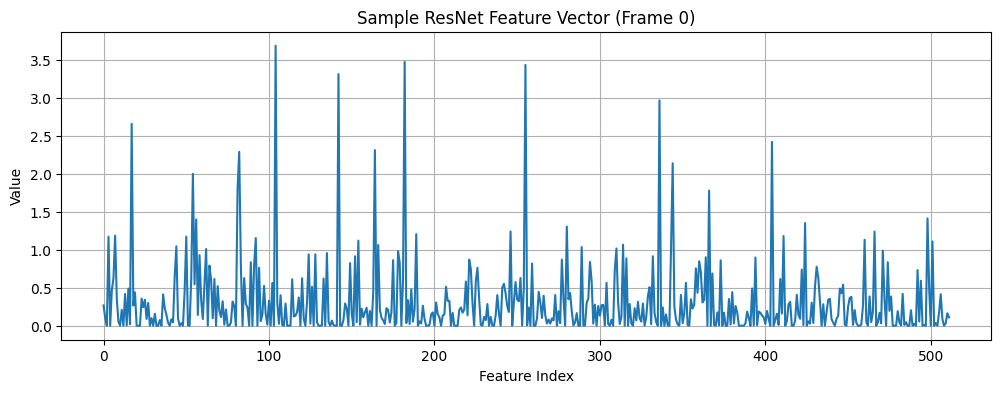

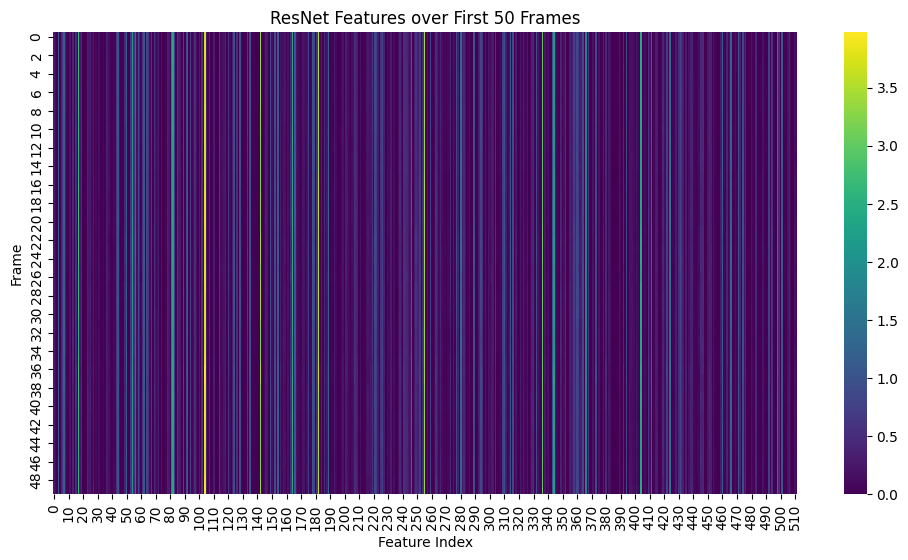

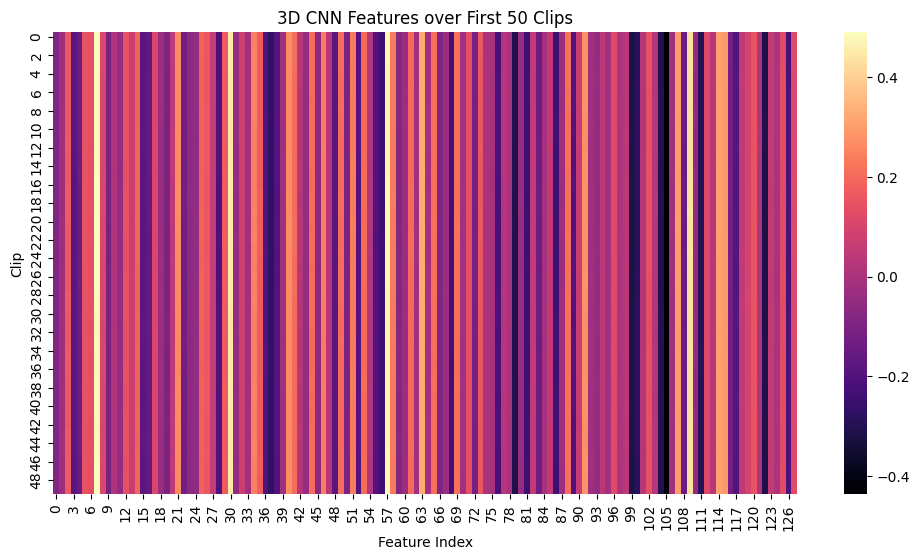

In [24]:
# ==============================================
# 4. Visualize Feature Vectors
# ==============================================
# Plot a sample ResNet feature vector
plt.figure(figsize=(12, 4))
plt.plot(features_resnet[0])
plt.title("Sample ResNet Feature Vector (Frame 0)")
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# Heatmap for ResNet feature vectors
plt.figure(figsize=(12, 6))
sns.heatmap(features_resnet[:50], cmap="viridis", cbar=True)
plt.title("ResNet Features over First 50 Frames")
plt.xlabel("Feature Index")
plt.ylabel("Frame")
plt.show()

# Heatmap for 3D CNN feature vectors
plt.figure(figsize=(12, 6))
sns.heatmap(features_3dcnn[:50], cmap="magma", cbar=True)
plt.title("3D CNN Features over First 50 Clips")
plt.xlabel("Feature Index")
plt.ylabel("Clip")
plt.show()


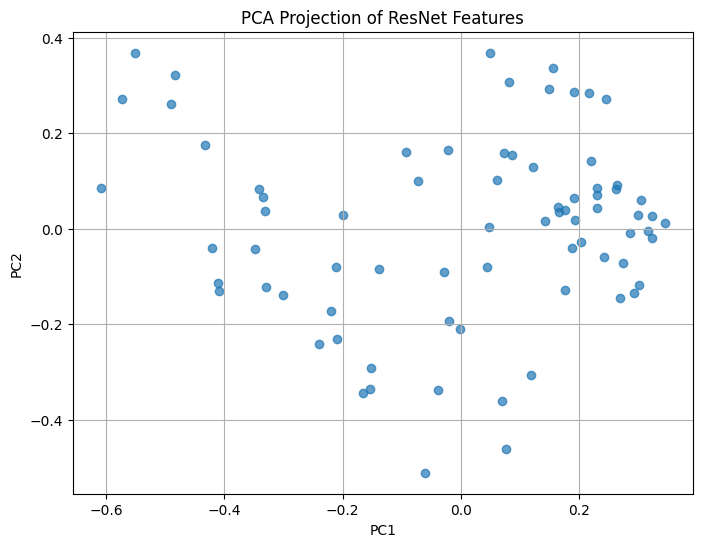

In [25]:
# ==============================================
# 5. PCA Projection
# ==============================================
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
pca = PCA(n_components=2)
pca_proj = pca.fit_transform(features_resnet)

plt.figure(figsize=(8,6))
plt.scatter(pca_proj[:,0], pca_proj[:,1], alpha=0.7)
plt.title("PCA Projection of ResNet Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


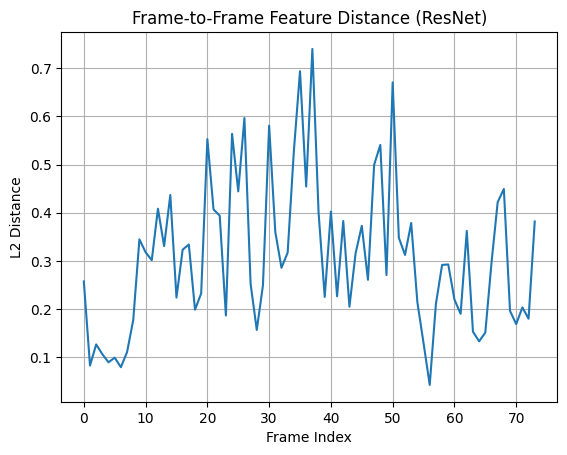

In [26]:
# ==============================================
# 6. Feature Temporal Smoothness
# ==============================================
# Compute L2 distance between consecutive ResNet feature vectors

deltas = np.linalg.norm(np.diff(features_resnet, axis=0), axis=1)
plt.plot(deltas)
plt.title("Frame-to-Frame Feature Distance (ResNet)")
plt.xlabel("Frame Index")
plt.ylabel("L2 Distance")
plt.grid(True)
plt.show()



In [27]:
# ==============================================
# 7. Evaluation Summary
# ==============================================
# Final diagnostic output to determine readiness for the next pipeline stage

print(f"2D ResNet features: {features_resnet.shape}")
print(f"3D CNN features: {features_3dcnn.shape}")
print("Mean L2 delta between ResNet frames:", np.mean(deltas))

if features_resnet.shape[0] >= 30 and np.mean(deltas) < 5:
    print("\n✅ Data looks good. Ready for Transformer training.")
else:
    print("\n⚠️ Consider revisiting preprocessing or model settings.")


2D ResNet features: (75, 512)
3D CNN features: (60, 128)
Mean L2 delta between ResNet frames: 0.30891877

✅ Data looks good. Ready for Transformer training.
